In [1]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install imbalanced-learn
%pip install scikit-learn
%pip install joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Crop and fertilizer dataset.csv'

import pandas as pd

# Load the dataset
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())

print("\nDataset information (column names, data types, and missing values):")
print(data.info())

Mounted at /content/drive
First few rows of the dataset:
  District_Name Soil_color  Nitrogen  Phosphorus  Potassium   pH  Rainfall  \
0      Kolhapur      Black        75          50        100  6.5      1000   
1      Kolhapur      Black        80          50        100  6.5      1000   
2      Kolhapur      Black        85          50        100  6.5      1000   
3      Kolhapur      Black        90          50        100  6.5      1000   
4      Kolhapur      Black        95          50        100  6.5      1000   

   Temperature       Crop Fertilizer                          Link  
0           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
1           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
2           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
3           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  
4           20  Sugarcane       Urea  https://youtu.be/2t5Am0xLTOo  

Dataset information (column names, data types, and missing 

In [57]:
# Filter the dataset for rice-related data only
rice_data = data[data['Crop'].str.lower() == 'rice']

# Drop irrelevant columns
rice_data = rice_data.drop(columns=['District_Name', 'Soil_color', 'Link', 'Crop'])

# Check for missing values
missing_values = rice_data.isnull().sum()

# Check for duplicate rows
duplicates = rice_data.duplicated().sum()

print(rice_data.head())
print(rice_data.shape)




     Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature Fertilizer
624        20          15         20  5.5       700           25       Urea
625        25          15         20  5.5       700           25       Urea
626        30          15         20  5.5       700           25       Urea
627        20          20         25  6.0       800           30       Urea
628        25          20         25  6.0       800           30       Urea
(309, 7)


In [58]:
# Encode the target variable (Fertilizer)
rice_data['Fertilizer_encoded'] = rice_data['Fertilizer'].astype('category').cat.codes

# Display the mapping of fertilizer categories
fertilizer_mapping = dict(enumerate(rice_data['Fertilizer'].astype('category').cat.categories))

fertilizer_mapping

{0: '50:26:26 NPK', 1: 'Urea'}

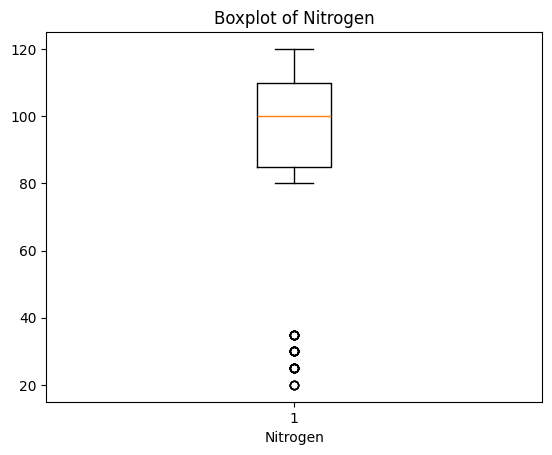

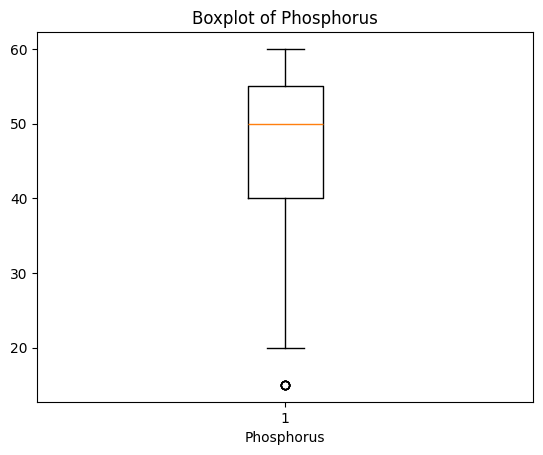

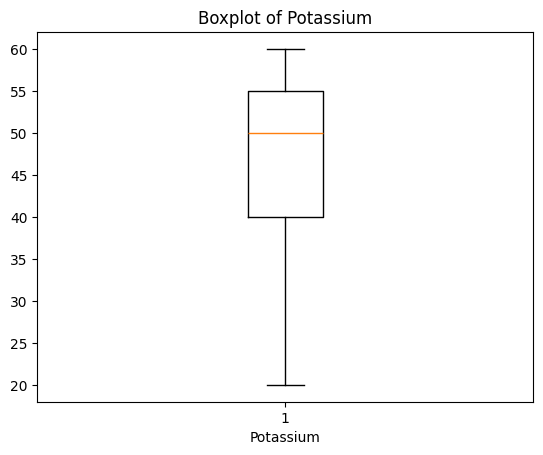

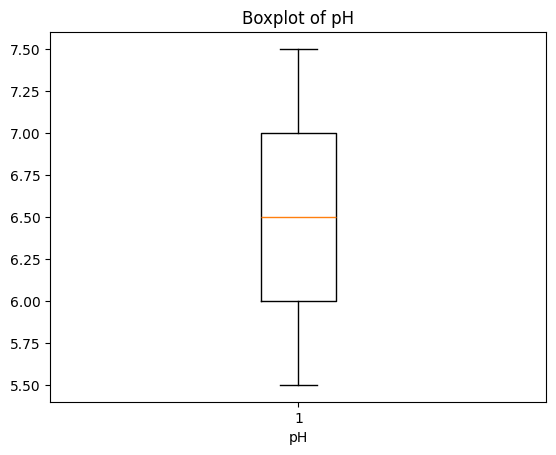

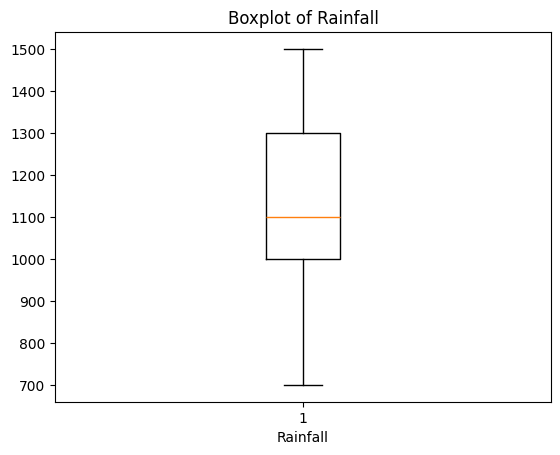

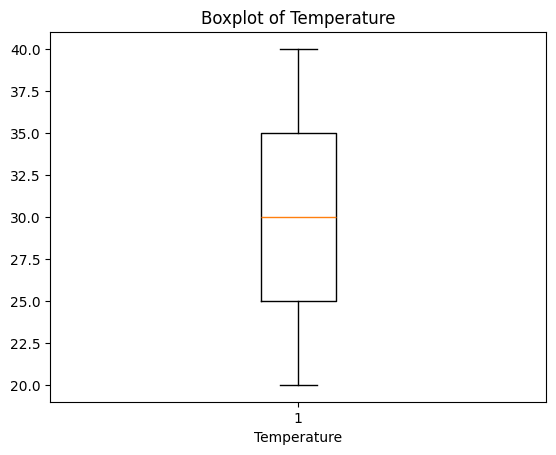

In [59]:
import matplotlib.pyplot as plt

# Check for outliers using boxplots
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']

# Plot boxplots for each numerical feature to identify outliers
for feature in numerical_features:
    plt.figure()
    plt.boxplot(rice_data[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()




In [60]:
# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Removing outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply the function to numerical features
numerical_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
rice_data_cleaned = remove_outliers_iqr(rice_data, numerical_features)

# Display the cleaned data after outlier removal
print("Rice Dataset After Removing Outliers\n", rice_data_cleaned)


Rice Dataset After Removing Outliers
       Nitrogen  Phosphorus  Potassium   pH  Rainfall  Temperature Fertilizer  \
2167        80          40         40  6.0      1000           25       Urea   
2168        85          40         40  6.0      1000           25       Urea   
2169        90          40         40  6.0      1000           25       Urea   
2170        95          40         40  6.0      1000           25       Urea   
2171       100          40         40  6.0      1000           25       Urea   
...        ...         ...        ...  ...       ...          ...        ...   
4074       100          60         55  6.5       900           35       Urea   
4075       105          60         55  6.5       900           35       Urea   
4076       110          60         55  6.5       900           35       Urea   
4077       115          60         55  6.5       900           35       Urea   
4078       120          60         55  6.5       900           35       Urea   

 

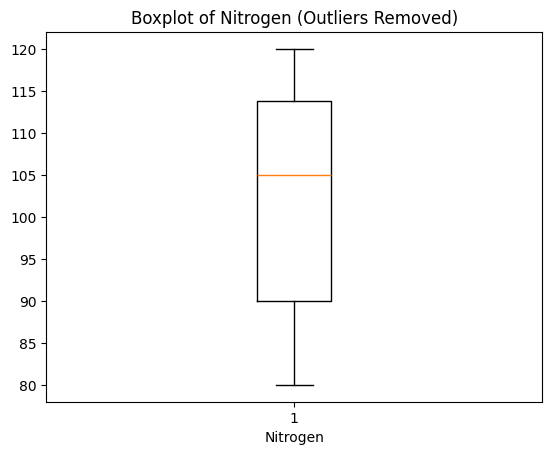

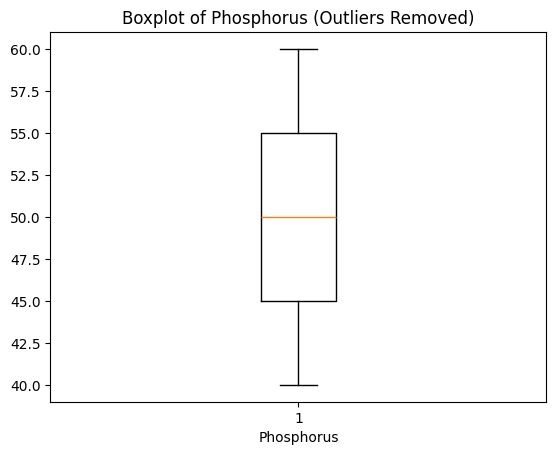

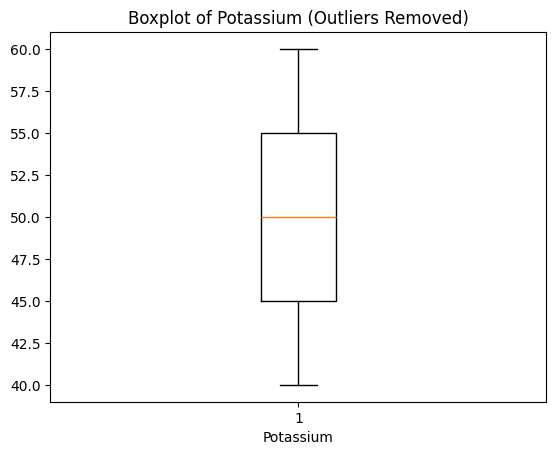

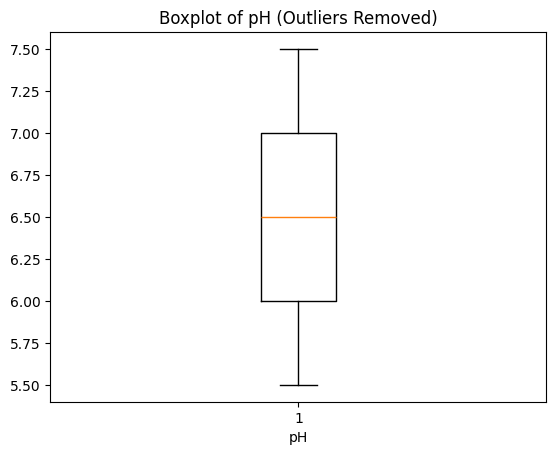

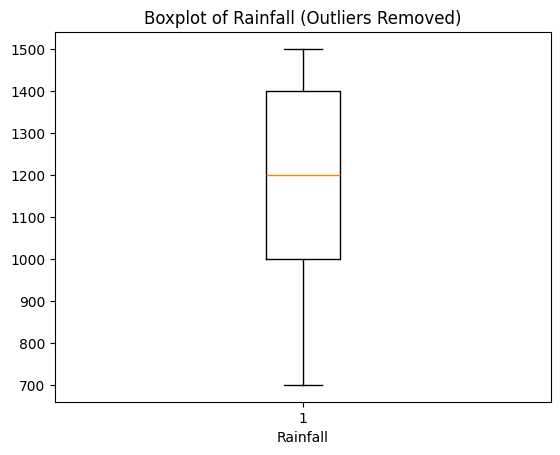

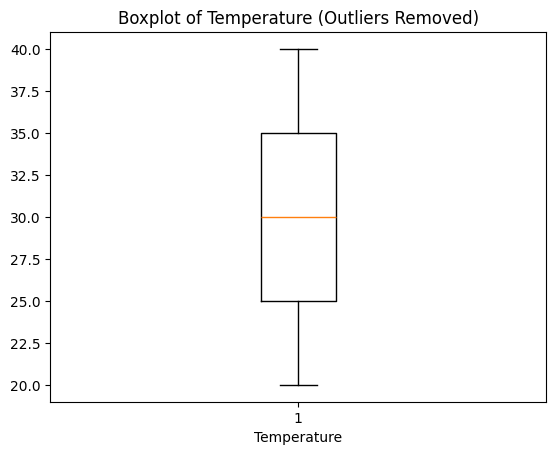

In [61]:
# Plot boxplots for each numerical feature after outlier removal
for feature in numerical_features:
    plt.figure()
    plt.boxplot(rice_data_cleaned[feature])
    plt.title(f'Boxplot of {feature} (Outliers Removed)')
    plt.xlabel(feature)
    plt.show()

In [62]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Features and target
X = rice_data_cleaned[['Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']]
y = rice_data_cleaned['Fertilizer_encoded']

# Split the data before applying Min-Max Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on the training set only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))


Before SMOTE: Counter({1: 132, 0: 84})
After SMOTE: Counter({1: 132, 0: 132})


In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply Min-Max Scaling to the training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Apply the same transformation to the test data
X_test_scaled = scaler.transform(X_test)

# Check the scaled data
import pandas as pd
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Min-Max Scaled Training Data\n", scaled_df)


Min-Max Scaled Training Data
      Nitrogen  Phosphorus  Potassium    pH  Rainfall  Temperature
0       0.125        1.00       1.00  0.25     0.875         0.50
1       0.875        0.50       1.00  0.25     0.375         0.25
2       0.750        0.25       0.00  0.50     0.750         0.25
3       0.875        0.50       0.00  0.50     1.000         0.75
4       0.625        0.00       0.50  0.75     0.875         0.50
..        ...         ...        ...   ...       ...          ...
259     0.500        1.00       0.00  0.50     0.750         0.25
260     0.275        0.25       0.50  0.75     0.375         0.25
261     0.525        0.00       0.25  0.50     1.000         0.75
262     0.475        0.70       0.25  0.75     0.375         0.25
263     0.150        1.00       0.00  0.50     0.750         0.25

[264 rows x 6 columns]


In [64]:
import pandas as pd

# Define the path where you want to save the file
file_path = "/content/drive/My Drive/final_preprocessed_dataset.csv"

# Convert the final preprocessed dataset to a DataFrame
final_preprocessed_df = pd.DataFrame(X_train_scaled, columns=X.columns)
final_preprocessed_df['Fertilizer_encoded'] = y_train_smote  # Adding target column back

# Save the dataset to Google Drive
final_preprocessed_df.to_csv(file_path, index=False)

print(f"Final preprocessed dataset saved successfully at: {file_path}")


Final preprocessed dataset saved successfully at: /content/drive/My Drive/final_preprocessed_dataset.csv


In [56]:
# mlp classifier

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Initialize and train the MLP Classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_classifier.fit(X_train_scaled, y_train_smote)

# Make predictions on the test set
y_pred = mlp_classifier.predict(X_test_scaled)

# Evaluate the model
print("Classification Report for MLP Classifier on Test Set:\n", classification_report(y_test, y_pred))

# Evaluate the model on training set
y_pred_train = mlp_classifier.predict(X_train_scaled)
print("\nClassification Report for MLP Classifier on Train Set:\n", classification_report(y_train_smote, y_pred_train))


Classification Report for MLP Classifier on Test Set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        33

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Classification Report for MLP Classifier on Train Set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       132
           1       1.00      1.00      1.00       132

    accuracy                           1.00       264
   macro avg       1.00      1.00      1.00       264
weighted avg       1.00      1.00      1.00       264



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
